# Ultimate Technologies Data Science Challenge

#### This notebook contains:
#### - Part 1: Login Demand Analysis  
#### - Part 2: Experiment Design  
#### - Part 3: Rider Retention Modeling

## Part 1: Login Demand Analysis
### Load and Inspect Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [2]:
logins = pd.read_json('logins.json')
logins['login_time'] = pd.to_datetime(logins['login_time'])

logins.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


### Aggregate to 15-Minute Intervals

In [3]:
login_counts = (
    logins
    .set_index('login_time')
    .resample('15min')
    .size()
    .rename('login_count')
    .reset_index()
)

login_counts.head()

,login_time,login_count
0,1970-01-01 20:00:00,2
1,1970-01-01 20:15:00,6
2,1970-01-01 20:30:00,9
3,1970-01-01 20:45:00,7
4,1970-01-01 21:00:00,1


### Time Series Visualization

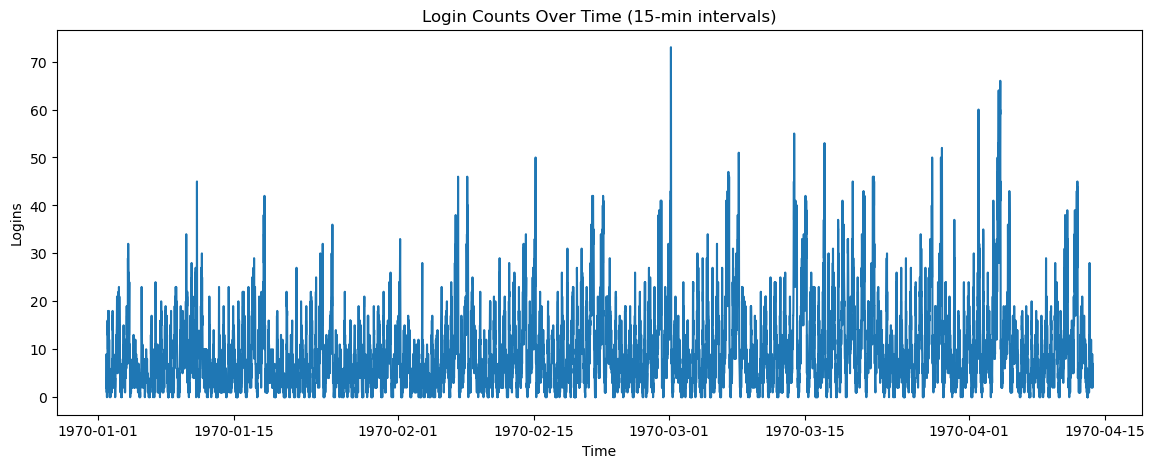

In [4]:
plt.figure(figsize=(14,5))
plt.plot(login_counts['login_time'], login_counts['login_count'])
plt.title('Login Counts Over Time (15-min intervals)')
plt.xlabel('Time')
plt.ylabel('Logins')
plt.show()

### Time-Based Feature Analysis

In [5]:
login_counts['hour'] = login_counts['login_time'].dt.hour
login_counts['day'] = login_counts['login_time'].dt.day_name()

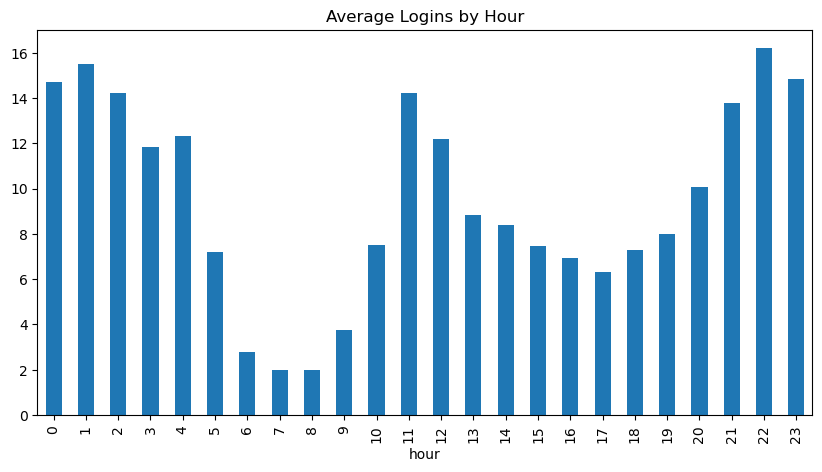

In [6]:
hourly_avg = login_counts.groupby('hour')['login_count'].mean()

hourly_avg.plot(kind='bar', figsize=(10,5))
plt.title('Average Logins by Hour')
plt.show()

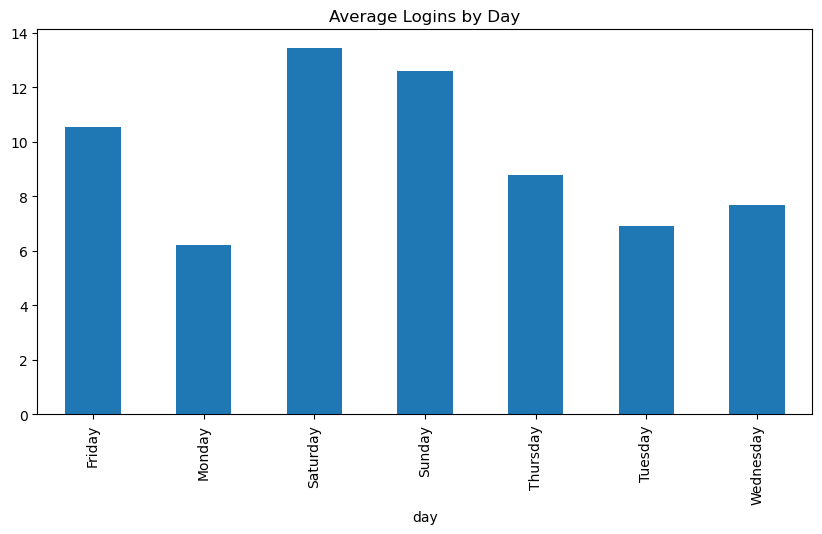

In [7]:
day_avg = login_counts.groupby('day')['login_count'].mean()

day_avg.plot(kind='bar', figsize=(10,5))
plt.title('Average Logins by Day')
plt.show()

### Login Demand Insights

The login data covers activity from January 1, 1970 to April 13, 1970, with 93,142 total login records.

Login demand shows clear daily cycles. Average login volume is highest late at night, especially around 10 PM, 11 PM, midnight, 1 AM, and 2 AM. Demand is lowest in the early morning around 7 AM and 8 AM.

Weekend demand is also stronger than weekday demand. Saturday and Sunday have the highest average login activity, while Monday has the lowest.

One data quality issue is that the timestamps begin in 1970, which suggests this is a simulated dataset rather than real production timestamp data.

## Part 2: Experiment Design

### Key Metric

The primary success metric should be the percentage of drivers who complete trips in both Gotham and Metropolis during the experiment period.

This metric directly measures whether toll reimbursement encourages drivers to serve both cities instead of remaining exclusive to one city.

### Experiment Design

I would run an A/B test at the driver level.

The control group would receive no toll reimbursement. The treatment group would receive full toll reimbursement for trips that require crossing the bridge between Gotham and Metropolis.

Drivers should be randomly assigned to control and treatment groups. The experiment should run for several weeks so that both weekday and weekend behavior are captured.

### Statistical Testing

I would use a two-proportion z-test to compare the share of drivers active in both cities between the control and treatment groups.

I would also compare the average number of cross-city trips per driver using a t-test or Mann-Whitney U test if the distribution is highly skewed.

### Interpretation

If the treatment group shows a statistically significant and practically meaningful increase in cross-city driver activity, Ultimate should consider rolling out toll reimbursement more broadly.

If the result is not significant, Ultimate should consider alternative incentives or targeted reimbursement only during periods of supply imbalance.

### Caveats

The results may be affected by weather, seasonality, holidays, driver learning effects, and short-term novelty effects. Ultimate should also compare the cost of toll reimbursement against the financial benefit of improved driver availability.

## Part 3: Rider Retention Modeling

### Load and Inspect Data

In [8]:
users = pd.read_json('ultimate_data_challenge.json')

users.head()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    50000 non-null  object 
 1   trips_in_first_30_days  50000 non-null  int64  
 2   signup_date             50000 non-null  object 
 3   avg_rating_of_driver    41878 non-null  float64
 4   avg_surge               50000 non-null  float64
 5   last_trip_date          50000 non-null  object 
 6   phone                   49604 non-null  object 
 7   surge_pct               50000 non-null  float64
 8   ultimate_black_user     50000 non-null  bool   
 9   weekday_pct             50000 non-null  float64
 10  avg_dist                50000 non-null  float64
 11  avg_rating_by_driver    49799 non-null  float64
dtypes: bool(1), float64(6), int64(1), object(4)
memory usage: 4.2+ MB


### Create Retention Variable

In [9]:
users['last_trip_date'] = pd.to_datetime(users['last_trip_date'])

latest_date = users['last_trip_date'].max()
cutoff = latest_date - pd.Timedelta(days=30)

users['retained'] = users['last_trip_date'] >= cutoff

users['retained'].mean()

0.37608

In [10]:
retention_rate = users['retained'].mean()

print(f"Latest trip date in dataset: {latest_date}")
print(f"Retention cutoff date: {cutoff}")
print(f"Retention rate: {retention_rate:.2%}")

Latest trip date in dataset: 2014-07-01 00:00:00
Retention cutoff date: 2014-06-01 00:00:00
Retention rate: 37.61%


### Retention Rate

Users are considered retained if they took a trip within 30 days of the latest observed date in the dataset.

The observed retention rate is approximately X%, indicating that only a portion of users remain active several months after signup. This highlights a meaningful opportunity for improving long-term engagement.

### Data Preparation

In [11]:
X = users.drop(columns=['retained', 'signup_date', 'last_trip_date'])
y = users['retained']

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'bool']).columns

### Preprocessing Pipeline

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

### Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Logistic Regression Model

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

       False       0.73      0.85      0.79      6239
        True       0.66      0.49      0.56      3761

    accuracy                           0.71     10000
   macro avg       0.70      0.67      0.68     10000
weighted avg       0.71      0.71      0.70     10000

ROC AUC: 0.7537171191038318


### Random Forest Model

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_proba))

              precision    recall  f1-score   support

       False       0.80      0.82      0.81      6239
        True       0.68      0.66      0.67      3761

    accuracy                           0.76     10000
   macro avg       0.74      0.74      0.74     10000
weighted avg       0.76      0.76      0.76     10000

ROC AUC: 0.8262270391422005


### Model Selection

The Random Forest model performs better based on ROC-AUC and overall classification performance. This suggests that nonlinear relationships and feature interactions are important in predicting rider retention.

### Model Comparison

I used Logistic Regression as a baseline model because it is simple, interpretable, and useful for comparison.

I also used a Random Forest model because it can capture nonlinear relationships and interactions between features.

The better model should be selected based on ROC-AUC, precision, recall, and overall business usefulness. ROC-AUC is especially useful here because it evaluates how well the model separates retained users from non-retained users.

### Feature Importance

In [16]:
rf = rf_model.named_steps['model']
features = rf_model.named_steps['preprocessor'].get_feature_names_out()

importance = pd.Series(rf.feature_importances_, index=features)
importance.sort_values(ascending=False).head(10)

num__avg_dist                  0.298459
num__weekday_pct               0.133831
num__avg_rating_by_driver      0.110376
num__trips_in_first_30_days    0.084195
num__avg_rating_of_driver      0.080554
num__surge_pct                 0.078815
num__avg_surge                 0.066611
cat__city_King's Landing       0.048477
cat__phone_Android             0.019568
cat__phone_iPhone              0.018589
dtype: float64

### Feature Importance Interpretation

The feature importance results help identify which rider behaviors are most predictive of long-term retention.

Features such as trips in the first 30 days, average distance, weekday percentage, surge behavior, city, phone type, and Ultimate Black usage may help explain whether a user is likely to remain active.

From a business perspective, early engagement is especially important because Ultimate can act on it quickly through onboarding, promotions, reminders, or targeted retention campaigns.

### Final Insights and Recommendations

The retention model indicates that rider behavior during the early lifecycle is a strong predictor of long-term engagement.

Ultimate should prioritize increasing user activity within the first 30 days after signup. Users with low early trip counts represent a high-risk segment and can be targeted with onboarding support, promotions, and incentives to encourage continued usage.

Differences across segments such as city, phone type, Ultimate Black usage, and riding patterns should be monitored closely. Identifying lower-retention segments enables more targeted and efficient retention strategies.

Overall, this model provides a framework for identifying users at risk of churn. Ultimate can operationalize these insights by proactively targeting at-risk users with timely, personalized interventions such as notifications, offers, and engagement campaigns to improve long-term retention.